In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mlt
import seaborn as sns

In [2]:
data = pd.read_csv("data/train(1).csv")
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

In [6]:
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
data.nunique()

id               16110
date               366
price             3428
bedrooms            12
bathrooms           29
sqft_living        881
sqft_lot          8048
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         803
sqft_basement      280
yr_built           116
yr_renovated        69
zipcode             70
lat               4775
long               708
sqft_living15      692
sqft_lot15        7279
dtype: int64

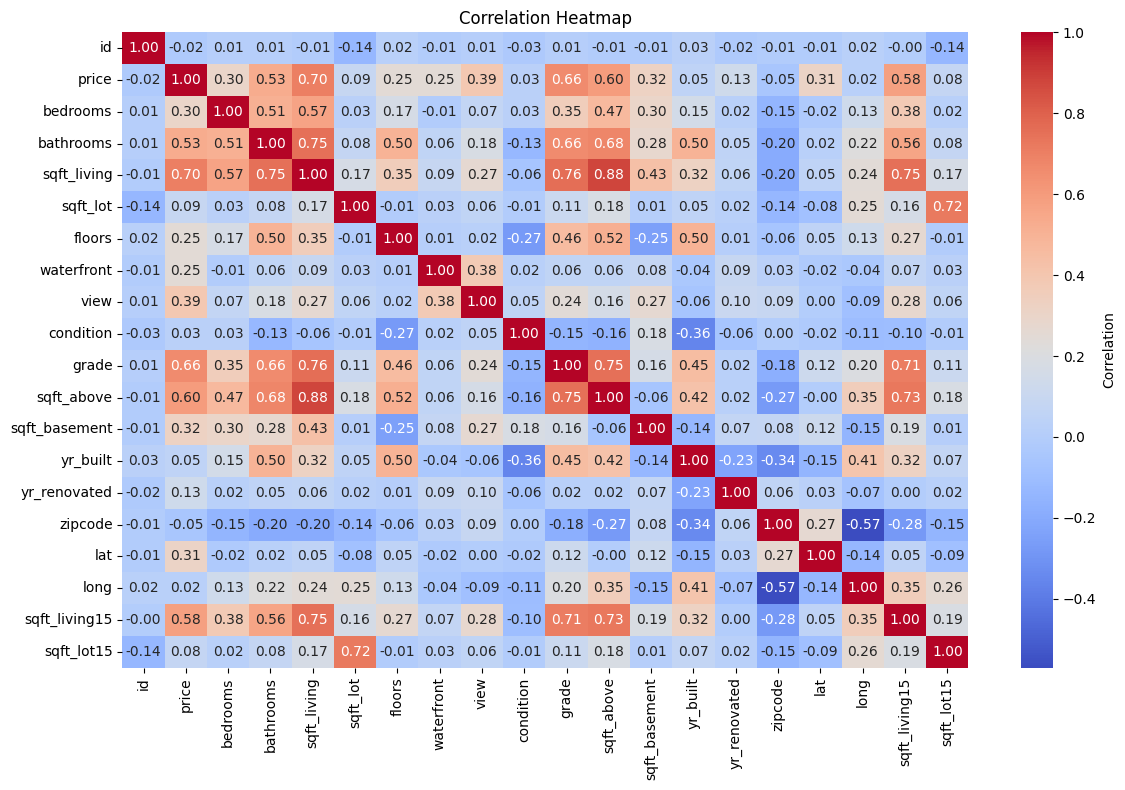

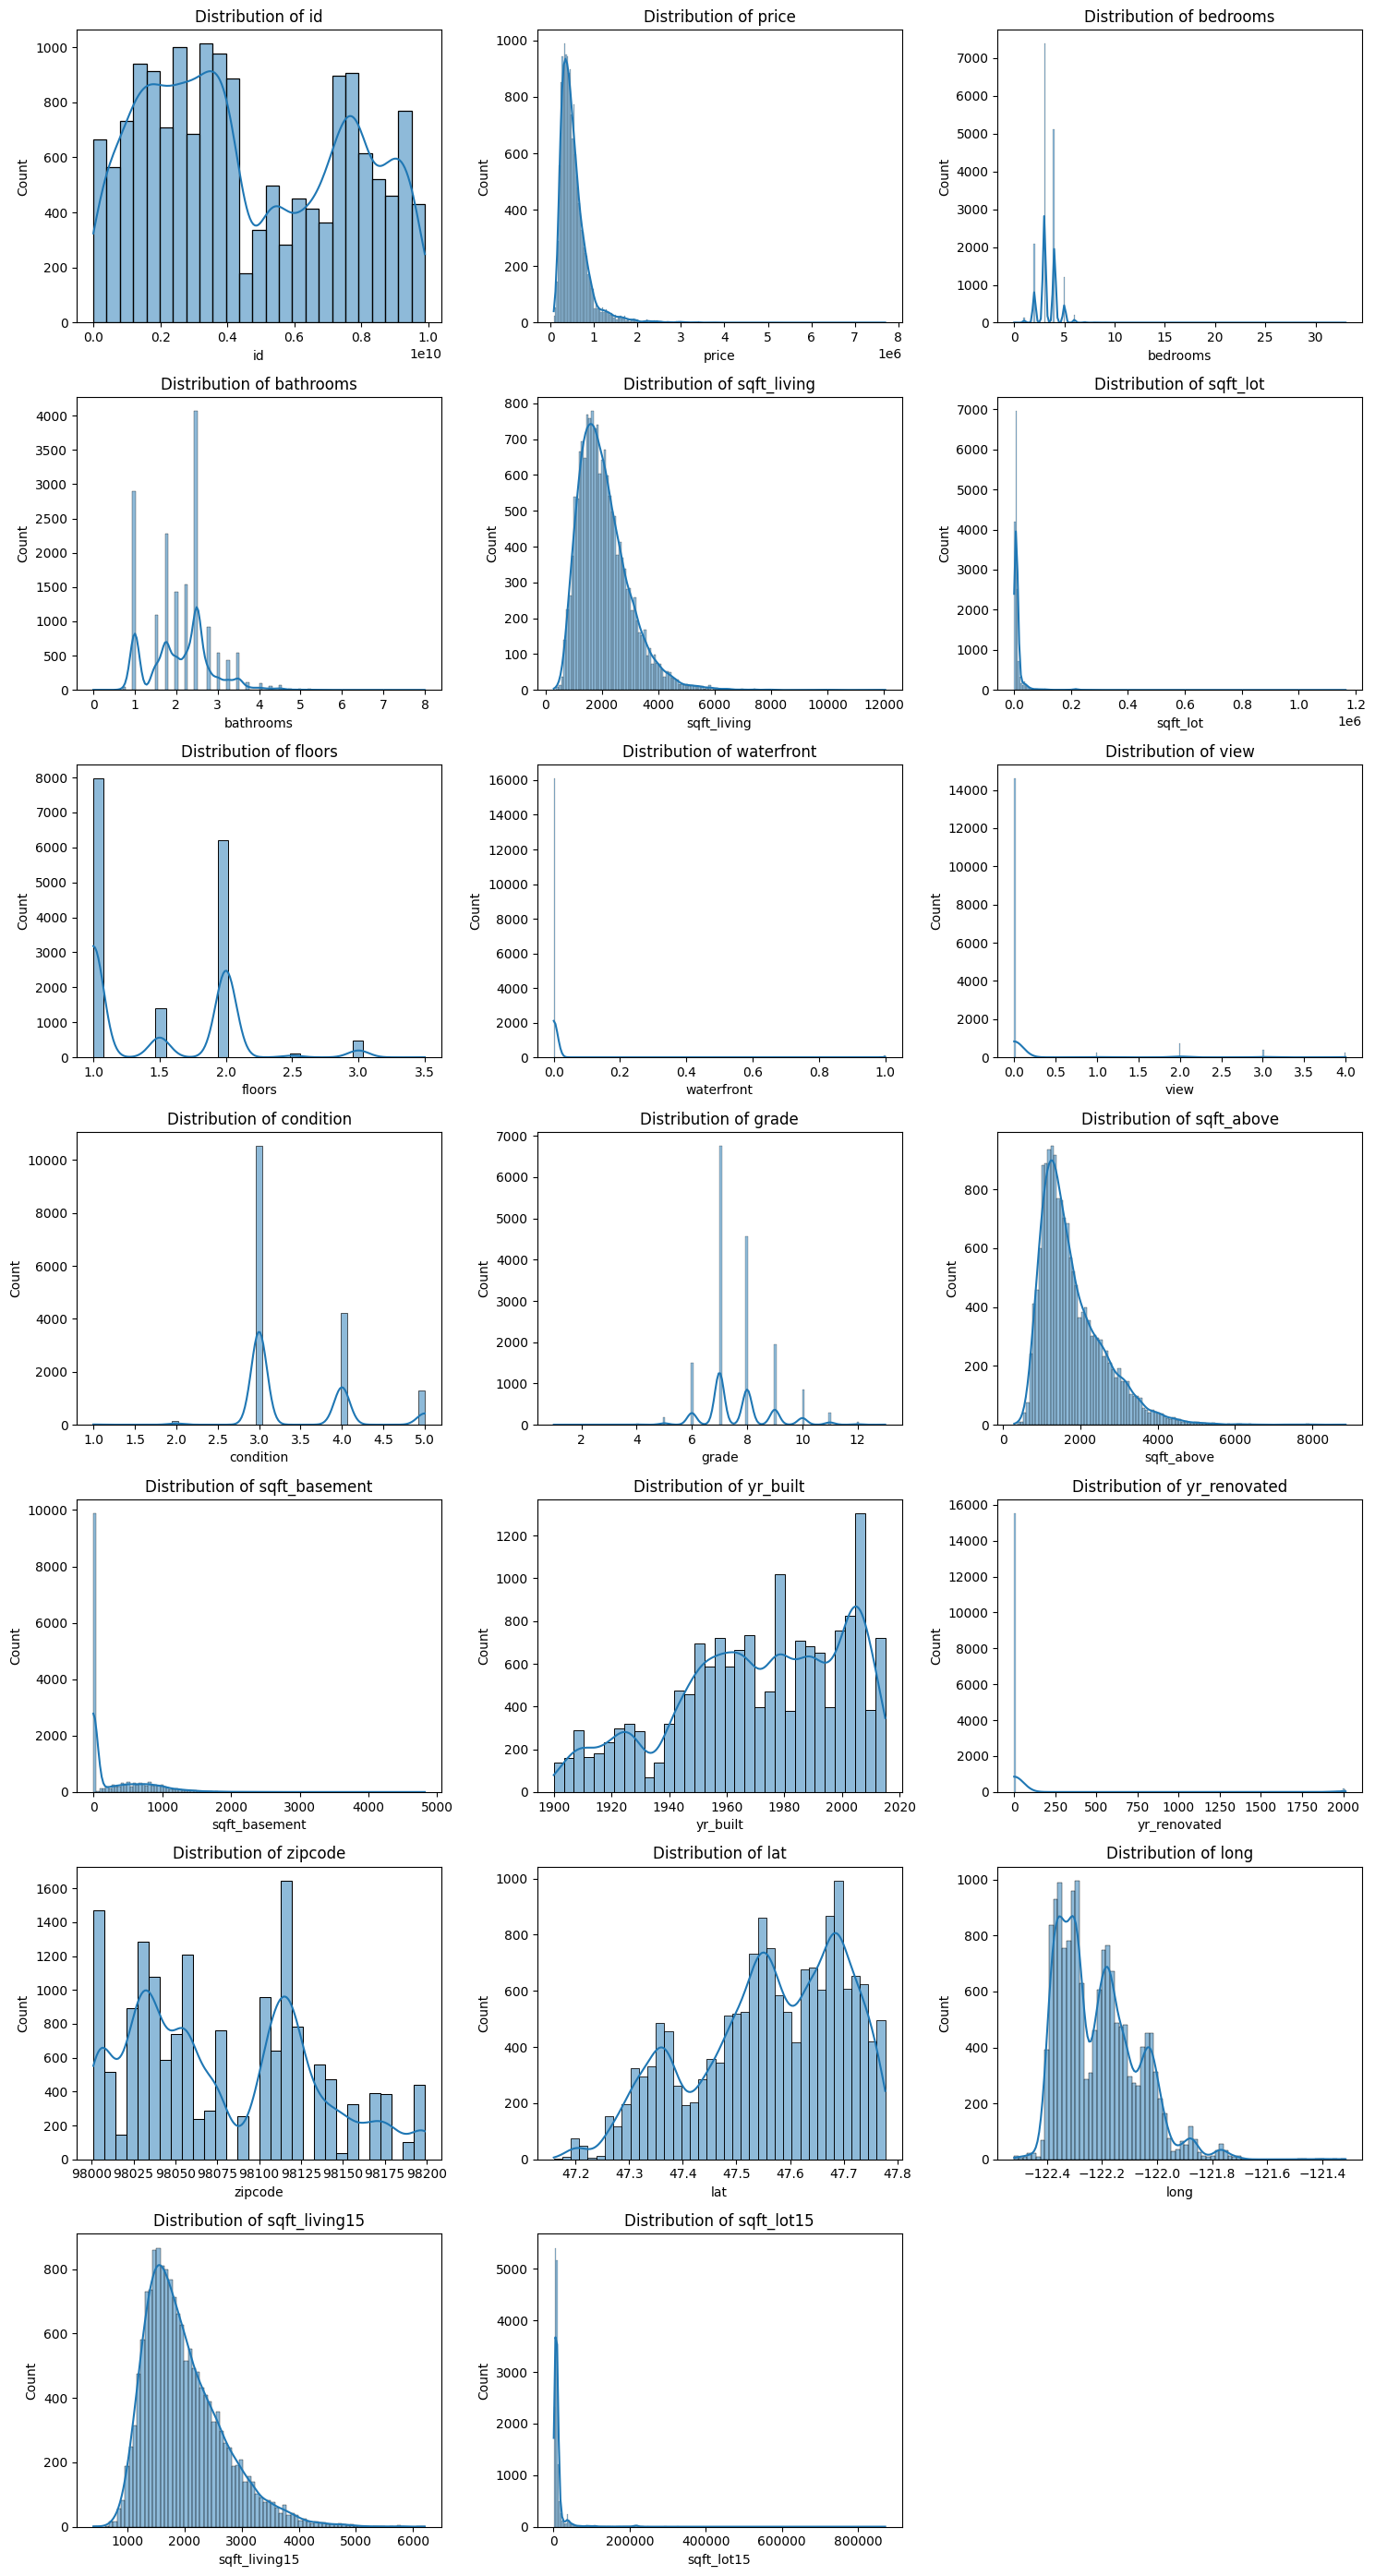

In [ ]:
mlt.figure(figsize=(12, 8))
corr_matrix = data.drop(columns='date', errors='ignore').corr().round(2)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Correlation'})
mlt.title("Correlation Heatmap")
mlt.tight_layout()
mlt.show()

num_cols = data.select_dtypes(include=np.number).columns
n_num = len(num_cols)
ncols = 3
nrows = (n_num + ncols - 1)// ncols
mlt.figure(figsize=(5 * ncols, 4 * nrows))
for i, col in enumerate(num_cols, 1):
    mlt.subplot(nrows, ncols, i)
    sns.histplot(data[col], kde=True)
    mlt.title(f"Distribution of {col}")
mlt.tight_layout()
mlt.show()

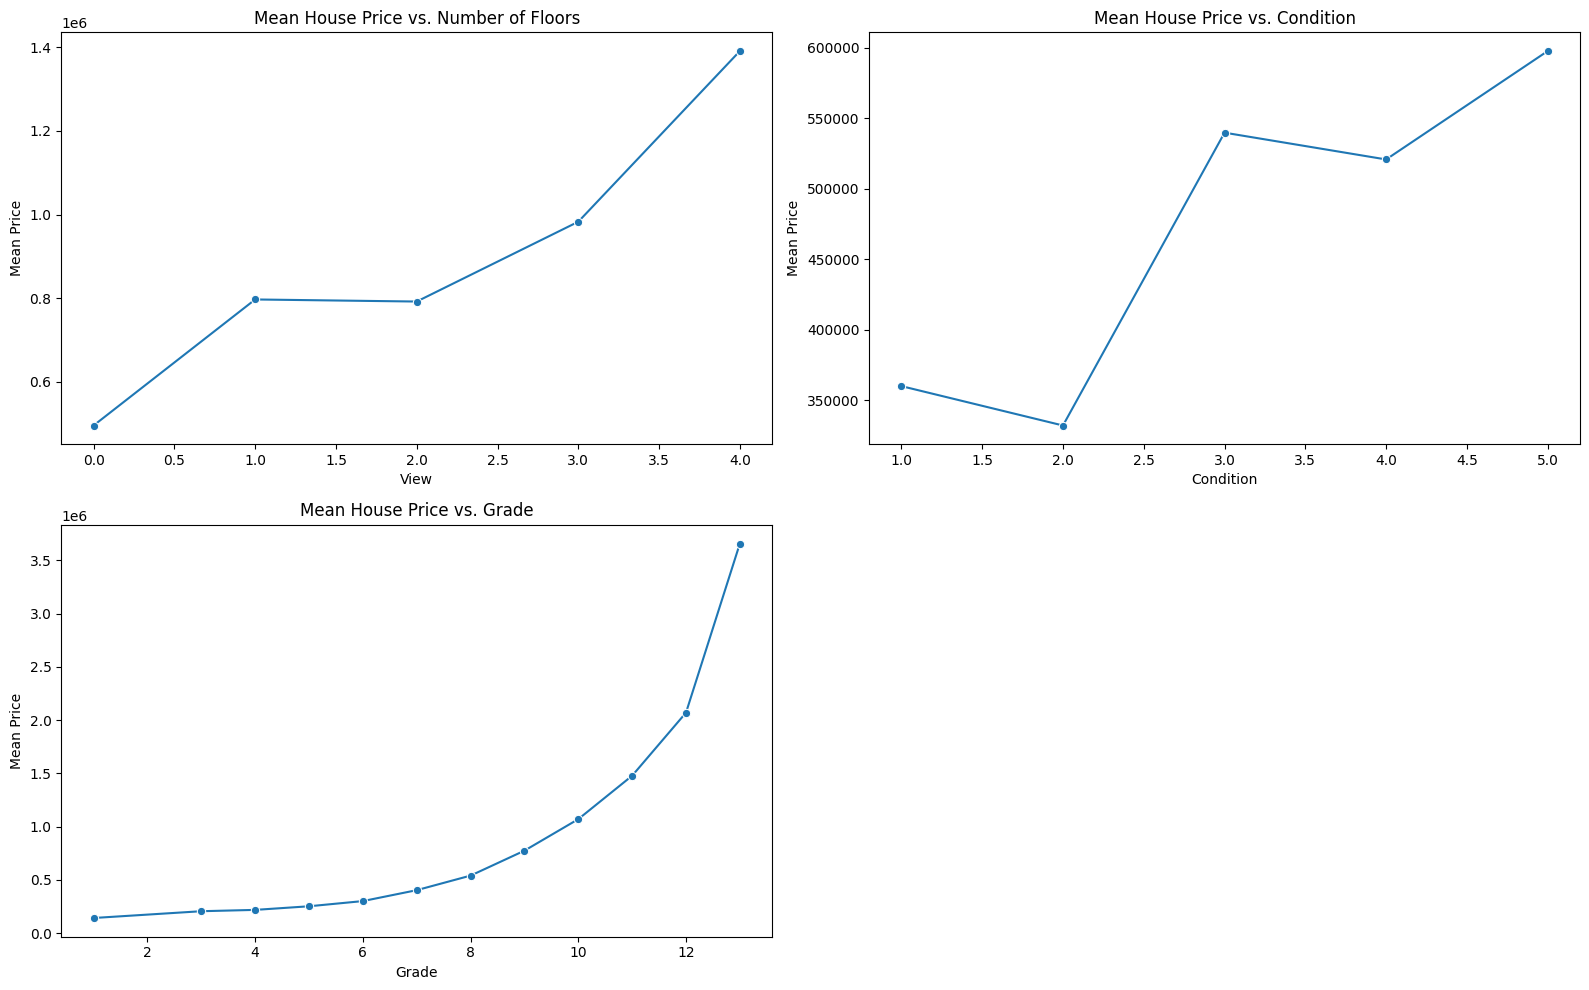

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
floors_mean = data.groupby('view')['price'].mean().reset_index()
sns.lineplot(x='view', y='price', data=floors_mean, marker='o')
plt.title('Mean House Price vs. Number of Floors')
plt.xlabel('View')
plt.ylabel('Mean Price')

plt.subplot(2, 2, 2)
condition_mean = data.groupby('condition')['price'].mean().reset_index()
sns.lineplot(x='condition', y='price', data=condition_mean, marker='o')
plt.title('Mean House Price vs. Condition')
plt.xlabel('Condition')
plt.ylabel('Mean Price')

plt.subplot(2, 2, 3)
grade_mean = data.groupby('grade')['price'].mean().reset_index()
sns.lineplot(x='grade', y='price', data=grade_mean, marker='o')
plt.title('Mean House Price vs. Grade')
plt.xlabel('Grade')
plt.ylabel('Mean Price')

plt.tight_layout()
plt.show()

Feature Extraction from Satellite Images

In [2]:
import cv2
import numpy as np
import os
import pandas as pd

image_folder = "images"
image_features = []

def extract_green_concrete_areas(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    green_mask = cv2.inRange(img_hsv, lower_green, upper_green)
    green_area = np.sum(green_mask > 0) / (img.shape[0] * img.shape[1])

    lower_concrete = np.array([0, 0, 60])
    upper_concrete = np.array([180, 50, 200])
    concrete_mask = cv2.inRange(img_hsv, lower_concrete, upper_concrete)
    concrete_area = np.sum(concrete_mask > 0) / (img.shape[0] * img.shape[1])

    return green_area, concrete_area

for fname in os.listdir(image_folder):
    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(image_folder, fname)
        green, concrete = extract_green_concrete_areas(path)
        image_features.append({
            "image": fname,
            "green_area_ratio": green,
            "concrete_area_ratio": concrete
        })

features_df = pd.DataFrame(image_features)
display(features_df)

,image,green_area_ratio,concrete_area_ratio
0,1000102.png,0.260681,0.702316
1,1001200050.png,0.287281,0.587723
2,1003000175.png,0.433411,0.471085
3,100300280.png,0.378262,0.588570
4,100300530.png,0.347446,0.636276
...,...,...,...
16105,993002127.png,0.274963,0.663708
16106,993002177.png,0.336346,0.600449
16107,993002225.png,0.358036,0.591309
16108,993002247.png,0.323448,0.614910


In [4]:
features_df.to_csv("image_features.csv",index=False)

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import os
import pandas as pd

model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*(list(model.children())[:-1]))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_folder = "images"
features = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(image_folder, fname)
        img = Image.open(img_path).convert('RGB')
        x = transform(img).unsqueeze(0)
        with torch.no_grad():
            feat = model(x).squeeze().numpy()
        features.append({
            "image": fname,
            "features": feat.flatten().tolist()
        })

features_df = pd.DataFrame(features)
display(features_df)
features_df.to_csv("cnn_image_features_pytorch.csv", index=False)

c:\Users\Arnav Agarwal\Desktop\CDC Project\.env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Arnav Agarwal\Desktop\CDC Project\.env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Arnav Agarwal/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%
c:\Users\Arnav Agarwal\Desktop\CDC Project\.env\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,image,features
0,1000102.png,"[2.6825897693634033, 0.9439875483512878, 2.558..."
1,1001200050.png,"[1.3670501708984375, 0.4120101034641266, 4.286..."
2,1003000175.png,"[0.6882113814353943, 0.150998055934906, 1.0609..."
3,100300280.png,"[1.959946632385254, 1.5071535110473633, 3.1896..."
4,100300530.png,"[0.9337612986564636, 1.106658935546875, 2.5806..."
...,...,...
16105,993002127.png,"[0.7397616505622864, 0.4660069942474365, 2.102..."
16106,993002177.png,"[1.2582952976226807, 0.1251770257949829, 1.930..."
16107,993002225.png,"[1.5914479494094849, 0.014997197315096855, 3.0..."
16108,993002247.png,"[0.8024211525917053, 0.11330020427703857, 2.32..."
